# 25. The Sounding Image: From Pixels to Sound

Every system in this book has drawn its output. Today we change the output device: the fern from chapter 7 will not be plotted, it will be *performed*, one oscillator per row of pixels, and then a spectrogram will develop the performance back into a picture. The book's ideas were never about pixels; they were about structure, and structure can be heard.

## Today's destination

This is a picture of a sound: the **spectrogram** of a six-second chord-cloud, time running left to right, pitch bottom to top, brightness showing how loudly each frequency sounds at each moment. It is also, unmistakably, chapter 7's fern, lying on its side. That is because the sound was *synthesized from the fern*: every row of a small image of the plant drove one sine oscillator, and what you see here is the sound remembering the image it came from. By the end of today you can perform any image in this book, and hide any image in a sound.

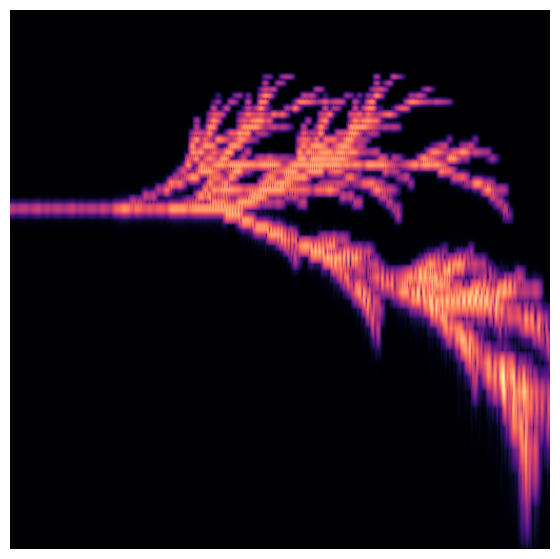

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch25_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(11, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: hearing pictures, seeing sound

In 1896, at a Moscow performance of Wagner's *Lohengrin*, the young **Wassily Kandinsky** had the experience he would retell for the rest of his life: "I saw all my colors in my mind; they stood before my eyes." Whether Kandinsky was a clinical synesthete or cultivated the crossing of the senses as an artistic program is still debated (the neuroscience literature calls it an open case), but the program itself is beyond doubt: *Concerning the Spiritual in Art* (1911) reads painting through the vocabulary of music, and his artist's book *Klänge* ("Sounds", Piper, 1912/13) sets 38 prose poems among 56 woodcuts, an album you are meant to hear. Painting, for Kandinsky, aspired to the condition of music because music was the art form that needed no objects.

Film gave the aspiration a mechanism. A film's optical soundtrack is a *picture*, a strip of varying light printed beside the frames, read by a photocell; and a picture that is read as sound can be *drawn*. In Berlin around 1932, **Oskar Fischinger** photographed painted ornaments directly onto the soundtrack, his *Tönende Ornamente*: "these ornaments are drawn music, they are sound," he wrote. At the National Film Board of Canada, **Norman McLaren** spent decades on the same idea, photographing striped cards onto the track; his Oscar-winning *Neighbours* (1952) is scored entirely with such synthetic sound, and *Synchromy* (1971) puts the very patterns you are hearing on screen as you hear them. **Iannis Xenakis** then removed the film: his UPIC system (1977), a drawing board wired to a computer, turned drawn arcs directly into sound, and *Mycènes Alpha* (1978) became the first work composed entirely on the UPIC.

Our own tools' direct ancestor arrived with **MetaSynth** (Eric Wenger, 1997), software in which you paint an image and hear it: each row of pixels drives an oscillator, brightness is loudness, exactly the machine we will build below from numpy alone. Its most famous secret lives on **Aphex Twin's** *Windowlicker* single (1999): the B-side track titled with a mathematical formula hides, in its final half-minute, a grinning face, visible to anyone who looks at the sound through a logarithmic spectrogram, and reportedly painted into the music with MetaSynth. (Venetian Snares hid photographs of his cats the same way in 2001. The medium attracts a certain humor.)

The chapter's thesis is the one this whole book has been quietly assuming: none of our systems were ever about *pixels*. They were about structure, and a spectrogram is just an image whose vertical axis happens to be pitch. So everything the book generates can be performed, and by the end of the chapter, one thing it generated will be.

## Sound as numbers

Sound is pressure changing over time; digital sound is that pressure *sampled*, measured thousands of times per second and stored as a numpy array. Our **sampling rate** (Abtastrate) throughout is 22050 samples per second, half of CD quality and plenty for our purposes. The simplest sound worth making is the sine wave,

$$y(t) = A \sin(2\pi f t),$$

with $A$ the **amplitude** (loudness) and $f$ the **frequency** in hertz: how many times per second the pressure swings through its full cycle. The note A below middle C swings 220 times a second. Chapter 3 taught you everything in this formula; the only news is that today the sine's output goes to your ears. Run the cell, look at the first few hundredths of a second, then press play:

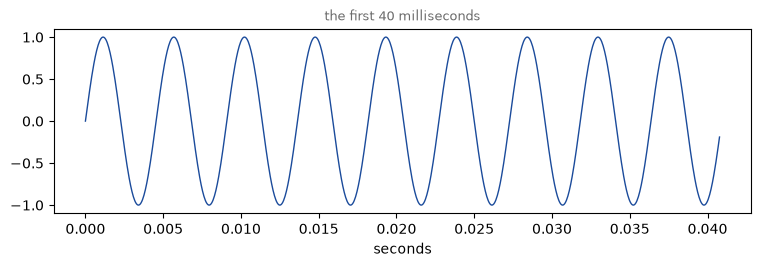

In [2]:
# two seconds of a pure sine at 220 Hz: see it, then hear it
import numpy as np
from IPython.display import Audio

RATE = 22050
t = np.arange(2 * RATE) / RATE          # sample times: 0, 1/22050, 2/22050, ...
tone = np.sin(2 * np.pi * 220 * t)

plt.figure(figsize=(9, 2.4))
plt.plot(t[:900], tone[:900], color="#1B4B9B", lw=1)
plt.xlabel("seconds")
plt.title("the first 40 milliseconds", fontsize=9, color="#6B6B6B")
plt.show()
# embed=True stores the sound inside the notebook, so the book page can play it
Audio(tone, rate=RATE, embed=True)

## Timbre: why a note is more than a pitch

A violin and a flute playing the same A do not sound alike, and the difference is not pitch but **timbre** (Klangfarbe, literally "sound-color": the vocabulary of chapter 6 was here first). A real note carries **harmonics**, quieter companion sines at whole-number multiples of the base frequency (counting the base itself as the first harmonic), and the *recipe of their loudnesses* is the timbre. Two demonstrations: a three-note chord (three sines at different pitches, sounding together), then the same low A twice, once pure and once with ten harmonics at falling loudness, which pushes it toward the reedy buzz of a bowed string.

In [3]:
# a chord is sines added; a timbre is harmonics added
from IPython.display import display

# display() lets one cell show several players (and prints between them)
chord = (np.sin(2 * np.pi * 220 * t) + np.sin(2 * np.pi * 277.18 * t)
         + np.sin(2 * np.pi * 329.63 * t)) / 3
print("a chord: A, C sharp, E")
display(Audio(chord, rate=RATE, embed=True))

rich = np.zeros_like(t)
for harmonic in range(1, 11):
    rich += np.sin(2 * np.pi * 110 * harmonic * t) / harmonic
rich = rich / np.abs(rich).max()
print("the same low A: pure, then with ten harmonics")
display(Audio(np.sin(2 * np.pi * 110 * t), rate=RATE, embed=True))
display(Audio(rich, rate=RATE, embed=True))

a chord: A, C sharp, E


the same low A: pure, then with ten harmonics


**Try it.** In the `rich` loop, keep only the odd harmonics (`range(1, 11, 2)`): the buzz hollows out toward a clarinet. The harmonic recipe is a palette, and you have just re-mixed it.

## The image as score

Now the chapter's central move. **Additive synthesis** builds sound from many oscillators, and nothing says their loudnesses must be constant. Take a small image, say 64 rows by 128 columns. Give every *row* its own oscillator at its own frequency, high rows high pitch. Read the *columns* as time, left to right. Let each pixel's brightness set how loudly that row's oscillator plays during that column's slice of time:

$$\mathrm{song}(t) \;=\; \sum_{\mathrm{row}} \mathrm{brightness}_{\mathrm{row}}(t) \cdot \sin(2\pi f_{\mathrm{row}} t).$$

An image read this way is called a **score**, because that is literally what a musical score is: a graph of pitch against time, darkness marking where the notes are. (Our instrument will also hand each oscillator a random starting phase from a seeded rng; without that, all 64 sines would peak together at $t = 0$ and every performance would open with a thump.) Every image-to-sound instrument since the optical soundtrack works on some version of this idea.

Our image will be chapter 7's fern, the book's emblem, condensed below in the honest-reuse pattern chapter 6 taught (copy your own functions forward): the rewrite engine and the turtle, whole but stripped of commentary.

In [4]:
# chapter 7, condensed: the L-system engine and the turtle, copied forward
import math

def rewrite(axiom, rules, iterations):
    string = axiom
    for _ in range(iterations):
        next_string = ""
        for symbol in string:
            next_string = next_string + rules.get(symbol, symbol)
        string = next_string
    return string

def interpret(instructions, angle_degrees, step=1.0):
    x, y = 0.0, 0.0
    heading = math.pi / 2
    turn = math.radians(angle_degrees)
    stack, segments = [], []
    for symbol in instructions:
        if symbol == "F":
            x_new = x + step * math.cos(heading)
            y_new = y + step * math.sin(heading)
            segments.append(((x, y), (x_new, y_new)))
            x, y = x_new, y_new
        elif symbol == "+":
            heading = heading + turn
        elif symbol == "-":
            heading = heading - turn
        elif symbol == "[":
            stack.append((x, y, heading))
        elif symbol == "]":
            x, y, heading = stack.pop()
    return segments

fern_rules = {"X": "F-[[X]+X]+F[+FX]-X", "F": "FF"}
fern_segments = interpret(rewrite("X", fern_rules, 5), 22.5)
print(f"{len(fern_segments)} segments, ready to sing")

1488 segments, ready to sing


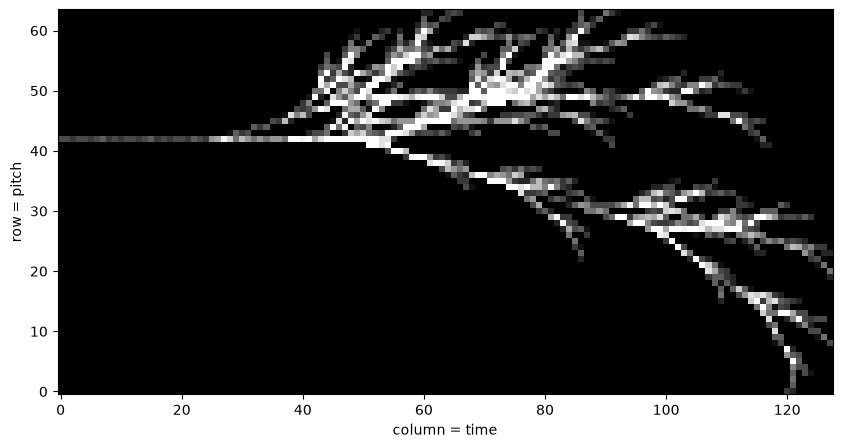

In [5]:
# rasterize the fern into a 64 x 128 score, lying on its side so time runs
# along its stem: the fern's y becomes time, its x becomes pitch
segments = np.array(fern_segments)              # shape (n, 2, 2)
blend = np.linspace(0, 1, 6)[:, None, None]     # 6 points along every segment at once
points = (segments[:, 0][None] * (1 - blend)
          + segments[:, 1][None] * blend).reshape(-1, 2)

N_ROWS, N_COLS = 64, 128
score, _, _ = np.histogram2d(points[:, 0], points[:, 1], bins=[N_ROWS, N_COLS])
score = np.clip(score / score.max() * 3, 0, 1)  # boost the thin lines

plt.figure(figsize=(10, 5))
plt.imshow(score, origin="lower", aspect="auto", cmap="gray")
plt.xlabel("column = time")
plt.ylabel("row = pitch")
plt.show()

(`np.histogram2d` counts how many sampled points land in each of the 64 by 128 cells, chapter 9's census of visits; `origin="lower"` puts row 0 at the bottom, where the low notes belong.)

One decision remains: *which* frequency does each row get? Ears hear multiplicatively: every doubling of frequency is one octave, the same musical distance. So we space the 64 frequencies **logarithmically** from 110 Hz to 1760 Hz (four octaves) with `np.geomspace`, chapter 20's multiplicative `linspace`; chapter 8 built the same log intuition for zooming. The singing loop is fifteen lines, and it is the whole instrument:

In [6]:
# the instrument: one oscillator per row, brightness driving loudness
def sing(score, f_low=110, f_high=1760, seconds=6.0, gamma=1.0, log_pitch=True,
         seed=19):
    rng = np.random.default_rng(seed)   # random phases: no collective thump at t=0
    n_rows, n_cols = score.shape
    if log_pitch:
        freqs = np.geomspace(f_low, f_high, n_rows)
    else:
        freqs = np.linspace(f_low, f_high, n_rows)
    t_audio = np.arange(int(RATE * seconds)) / RATE
    frame_times = np.linspace(0, seconds, n_cols)
    song = np.zeros(len(t_audio))
    for row in range(n_rows):
        if score[row].max() == 0:
            continue                             # silent rows cost nothing
        # np.interp glides between column brightnesses, so notes fade, not click
        envelope = np.interp(t_audio, frame_times, score[row]**gamma)
        song += envelope * np.sin(2 * np.pi * freqs[row] * t_audio
                                  + rng.uniform(0, 2 * np.pi))
    return song / np.abs(song).max() * 0.8

fern_song = sing(score)
print("the fern, performed:")
Audio(fern_song, rate=RATE, embed=True)

the fern, performed:


Press play. The stem is the piece's one continuous tone, a steady drone through the middle of the range; the fronds shower chimes above and below it; the whole plant takes six seconds to happen to you. It is not music exactly, and it is not noise: it is the fern's *structure*, which turns out to survive the change of medium.

**Try it.** `sing(score[::-1])` flips the plant upside down: same structure, inverted melody. And `sing(score, seconds=12)` grows it in slow motion.

## The circle closes: the spectrogram

Can we get the picture back out of the sound? This is where the chapter earns its subtitle. The **Fourier transform** reports which frequencies a signal contains, but over the *whole* signal at once, with no sense of *when*. The fix, and this is the idea to keep, is to analyze the sound through a **sliding window**: cut out a short piece (we use 1024 samples, about 46 milliseconds), fade its edges smoothly with `np.hanning`'s bell curve, ask numpy's `rfft` what frequencies live in that piece, slide forward a quarter-window, repeat. Stack the answers as columns and you have the **short-time Fourier transform** (STFT), displayed as the spectrogram: frequency against time, energy as brightness.

If a windowed wave sounds familiar, it should: chapter 16's Gabor filters are exactly this object, a bell-windowed sinusoid, aimed at images (Gabor's bell was a Gaussian; ours is the very similar Hann curve). That is no coincidence but a shared parent. In 1946 the physicist **Dennis Gabor** published "Theory of Communication", proposing to analyze sound in windowed sinusoid packets (his "elementary signals") precisely because pure Fourier analysis has no *when*; vision science later borrowed his functions to model the cortex, image people borrowed them back as filters, and here the roads meet: the spectrogram is a Gabor filter bank pointed at time instead of space.

We treat `rfft` itself as a black box (its inner workings are chapter-7-of-another-book material); what matters is what it reports: the strength of each frequency in the windowed piece (each output row is one **frequency bin**: a narrow band of pitches, chapter 2's histogram idea aimed at sound). The loop is honest and short:

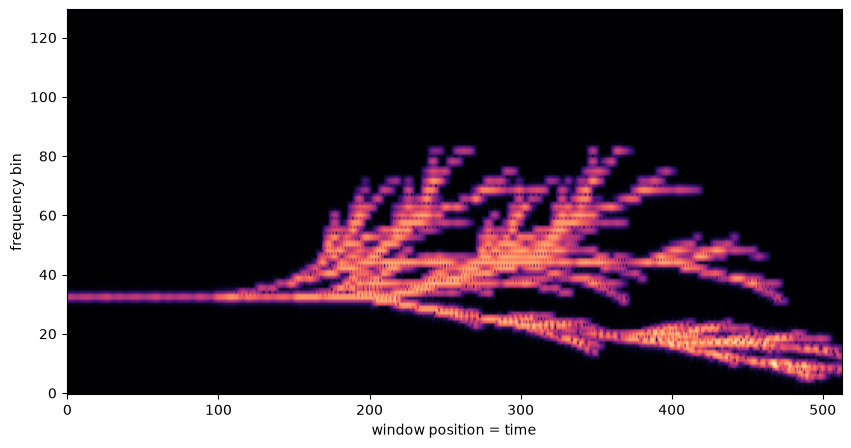

In [7]:
# the short-time Fourier transform by hand: window, transform, slide, stack
window, hop = 1024, 256
bell = np.hanning(window)                    # a smooth fade-in-fade-out curve

columns = []
for start in range(0, len(fern_song) - window, hop):
    piece = fern_song[start:start + window] * bell
    strengths = np.abs(np.fft.rfft(piece))   # how strong is each frequency here?
    columns.append(strengths)
spectrogram_manual = np.array(columns).T     # one column per window position

plt.figure(figsize=(10, 5))
plt.imshow(np.log1p(spectrogram_manual[:130]), origin="lower", aspect="auto",
           cmap="magma")
plt.xlabel("window position = time")
plt.ylabel("frequency bin")
plt.show()

The fern reappears, developed out of pure sound like a photograph out of a darkroom bath. (`np.log1p`, that is $\log(1+x)$, compresses the huge loudness range so faint harmonics stay visible, the same move as chapter 8's smooth coloring; we show only the first 130 frequency bins because our four octaves all live down there. Notice the plant is slightly *warped* compared with the score: we spaced our oscillators logarithmically but this display's frequency axis is linear. The showpiece at the chapter's end resamples the axis to log spacing, which undoes the warp.)

And, as always after building it ourselves: scipy has it packaged.

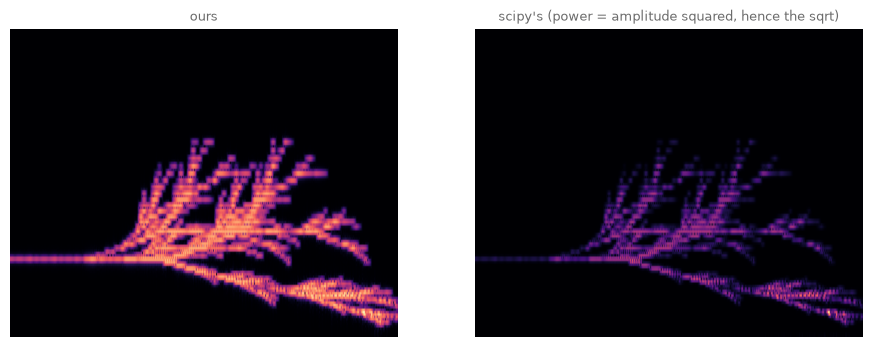

In [8]:
# the library version agrees (scipy.signal.spectrogram, same window, same hop)
from scipy.signal import spectrogram as scipy_spectrogram

bin_freqs, times, spectrogram_scipy = scipy_spectrogram(
    fern_song, fs=RATE, window="hann", nperseg=window, noverlap=window - hop)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(np.log1p(spectrogram_manual[:130]), origin="lower", aspect="auto",
               cmap="magma")
axes[0].set_title("ours", fontsize=9, color="#6B6B6B")
axes[1].imshow(np.log1p(np.sqrt(spectrogram_scipy[:130])), origin="lower",
               aspect="auto", cmap="magma")
axes[1].set_title("scipy's (power = amplitude squared, hence the sqrt)", fontsize=9,
                  color="#6B6B6B")
for ax in axes:
    ax.axis("off")
plt.show()

## Mapping studies: the same fern, other voices

Every arrow in the image-to-sound mapping was a choice, and choices have alternatives. Three studies, heard side by side with the original: **linear** pitch spacing (the fern's proportions in hertz instead of octaves: the treble crowds together and the image-to-ear honesty inverts, faithful to the numbers, false to the ear); a **gamma** on brightness (chapter 15's tone-map lesson, now audible: gamma 2 silences the faint pixels, gamma 0.5 lifts them); and **tempo** (the same structure in slow motion becomes weather rather than gesture).

In [9]:
# three remappings of the same score (excerpts kept short: sound is heavy)
print("linear pitch spacing (compare: the original was logarithmic)")
display(Audio(sing(score, log_pitch=False, seconds=5.0), rate=RATE, embed=True))
print("gamma 2: only the boldest pixels speak")
display(Audio(sing(score, gamma=2.0, seconds=5.0), rate=RATE, embed=True))
print("slow motion: ten seconds of weather")
display(Audio(sing(score, seconds=10.0), rate=RATE, embed=True))

linear pitch spacing (compare: the original was logarithmic)


gamma 2: only the boldest pixels speak


slow motion: ten seconds of weather


**Listen and compare.** Which mapping is most *faithful* to the fern? The question has no bottom: faithful to its geometry (linear), to its appearance to an ear (logarithmic), to its contrast (gamma)? Chapter 24 asked what a heatmap honestly shows; the same ethics applies when the display is a loudspeaker.

## Export your artwork

The gallery wants a picture, so we render a spectrogram as one: `spectrogram_art` below resamples the frequency axis to log spacing (undoing the warp, so the image shows the score that went in, with a little headroom above and below), maps it through a colormap, and enlarges with `np.kron`. Feed it your own remix of the fern, or a score of your own devising (any 2D array works: a chapter 13 spacetime diagram has strong opinions about rhythm). Replace `yourname` and run.

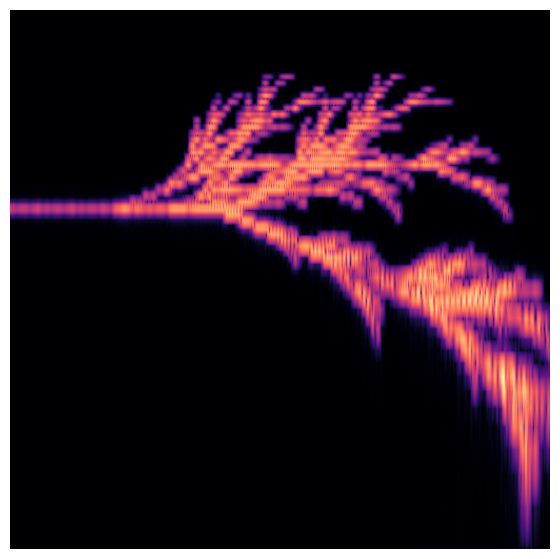

saved: assets/outputs/ch25_yourname.png


In [10]:
# save YOUR artwork: perform, photograph the performance, replace 'yourname'
import sys
sys.path.append("..")
from agap.helpers import save_artwork, show
from matplotlib import colormaps

def spectrogram_art(song, cmap="magma", rows=512, upscale=4):
    columns = []
    for start in range(0, len(song) - 1024, 256):
        columns.append(np.abs(np.fft.rfft(song[start:start + 1024]
                                          * np.hanning(1024))))
    spec = np.array(columns).T
    linear_bins = np.arange(spec.shape[0])
    log_bins = np.geomspace(3, 130, rows)   # linear -> log; our notes sit in bins ~5..82
    resampled = np.array([np.interp(log_bins, linear_bins, spec[:, col])
                          for col in range(spec.shape[1])]).T
    bright = np.log1p(resampled)
    bright = np.clip(bright / bright.max(), 0, 1)
    art = colormaps[cmap](bright)[::-1, :, :3]     # low notes at the bottom
    return np.kron(art, np.ones((upscale, upscale, 1)))

my_song = sing(score, seed=19)
my_artwork = spectrogram_art(my_song)
show(my_artwork)
saved_path = save_artwork(my_artwork, "yourname", chapter=25)

## Exercises

**(a) Parameter exploration: the mapping matrix.** Four performances: log and linear pitch spacing, each at gamma 0.5 and gamma 2. Listen to all four and describe each in one written sentence, using no technical vocabulary (pretend you are writing wall text for a listening room). Then answer: which single dial changed *what the piece is about*, and which merely changed its lighting?

**(b) Code modification: the color grid sings.** Chapter 2's weighted color grids were compositions in space; make one a composition in time. Build a small grid the chapter 2 way (weighted choice from a palette), read its columns as beats, and inside each column map every cell's **hue** to a note of the pentatonic table (A 220, C 261.63, D 293.66, E 329.63, G 392 Hz) and its **value** (brightness) to loudness. Five notes, no wrong chords: the pentatonic scale is the friendliest in music.

<details><summary>Solution</summary>

```python
import colorsys
from matplotlib.colors import to_rgb
from agap.helpers import PALETTES

PENTATONIC = [220.0, 261.63, 293.66, 329.63, 392.0]   # A, C, D, E, G

rng = np.random.default_rng(2)
kelly = PALETTES["kelly"]
weights = [0.3, 0.05, 0.05, 0.2, 0.2, 0.05, 0.05, 0.1]  # opinionated, chapter 2
grid = rng.choice(len(kelly), size=(6, 16), p=weights)

beat = 0.35                                   # seconds per column
t_note = np.arange(int(RATE * beat)) / RATE
fade = np.hanning(len(t_note))                # a bell per beat: no clicks
beats = []
for col in range(grid.shape[1]):
    chord = np.zeros(len(t_note))
    for row in range(grid.shape[0]):
        red, green, blue = to_rgb(kelly[grid[row, col]])
        hue, saturation, value = colorsys.rgb_to_hsv(red, green, blue)
        note = PENTATONIC[int(hue * len(PENTATONIC)) % len(PENTATONIC)]
        chord += value * np.sin(2 * np.pi * note * t_note)
    beats.append(chord * fade)
tune = np.concatenate(beats)
tune = tune / np.abs(tune).max() * 0.8
Audio(tune, rate=RATE, embed=True)
```

Each column becomes one bell-shaped chord of up to six pentatonic notes (duplicate hues double up and simply get louder), and the weighting does audible work: the dominant color becomes the drone of the piece, the rare accent becomes its surprise. Sixteen beats of chapter 2, and the reproducibility contract still holds: same seed, same tune.
</details>

**(c) Creative challenge: the hidden word.** The Aphex homage. Compose a small binary image of a short secret word (build block letters by slicing ones into an `np.zeros((16, 64))` array, or rasterize any drawing you like), use it as the score, and tune the mapping so the word is *inaudible as a word* but develops crisply in the spectrogram. Trade audio files with someone else from the course and decode each other. You now own the fact that every sound is an image and every image a sound; use it with discretion.

## Further reading

- Wassily Kandinsky, *Concerning the Spiritual in Art* (1911), free online at Project Gutenberg: the synesthetic program from the painter's own hand; short, strange, foundational.
- Thomas Y. Levin, "'Tones from out of Nowhere': Rudolph Pfenninger and the Archaeology of Synthetic Sound", *Grey Room* 12 (2003): the scholarly history of drawn sound, Fischinger included; library access.
- Center for Visual Music, centerforvisualmusic.org (free): the archive of Fischinger's films and papers, including his 1932 "Sounding Ornaments" text.
- Curtis Roads, *Microsound* (MIT Press, 2001): where Gabor's sound-quanta lead when composers take them literally; the technical deep end of this chapter's pool.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook: the sung fern's spectrogram, log-frequency axis, magma, print size. The sound it photographs is embedded above, where the fern first sang. It runs automatically with *Restart & Run All*.

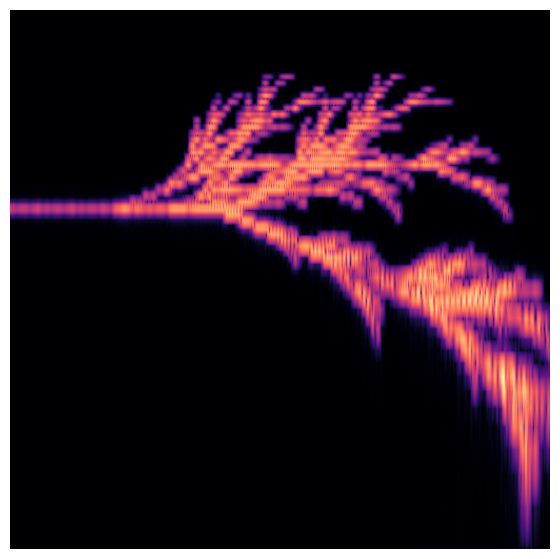

saved: assets/outputs/ch25_showpiece.png


In [11]:
# regenerate this chapter's showpiece: the fern, as its own spectrogram
showpiece = spectrogram_art(fern_song)
show(showpiece)
saved_path = save_artwork(showpiece, "showpiece", chapter=25)